### Cats vs Dogs Classification Using CNN

- This project aims to build a Convolutional Neural Network (CNN) from scratch to classify Cats and Dogs images into different categories.

- Understand how CNN works from scratch
- Preprocess image data for deep learning
- Build and train a CNN model
- Evaluate the model performance using accuracy and confusion matrix


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# data processing

import cv2
import imghdr
import os
import numpy as np
import matplotlib.pyplot as plt


/tmp/ipykernel_10246/1011284137.py:4: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


## => Data Cleaning

Before training the CNN model, it is important to clean the dataset.
Some image files may be:
- Corrupted
- Not actual images
- Unreadable by OpenCV

To handle this, we:
- Verify the file type using its actual content
- Remove invalid or corrupted image files
This ensures that only valid images are used during training.

In [5]:
data_dir = '/content/drive/MyDrive/data'
ext = ['png', 'jpg', 'jpeg', 'bmp']

for image_class in os.listdir(data_dir):
  class_path = os.path.join(data_dir, image_class)
  for image in os.listdir(class_path):
    image_path = os.path.join(class_path, image)
    image_ext = imghdr.what(image_path)

    if image_ext not in ext:
      os.remove(image_path)

    img = cv2.imread(image_path)
    if img is None:
      os.remove(image_path)

In [6]:
import tensorflow as tf

data = tf.keras.utils.image_dataset_from_directory(data_dir)


Found 697 files belonging to 2 classes.


This method automatically:
- Reads images from directory structure
- Assigns labels based on folder names
- Creates an efficient TensorFlow dataset pipeline

Using this approach simplifies data loading and improves performance
during training.



In [7]:
batch = data.as_numpy_iterator()
batch = batch.next()
batch

(array([[[[255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          ...,
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ]],
 
         [[255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          ...,
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ]],
 
         [[255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          ...,
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ]],
 
         ...,
 
         [[2

This step helps verify:
- Image shape and dimensions
- Batch size
- Correct label assignment

Inspecting the data early ensures that the dataset is correctly loaded
before model training.

## => Data Visualization


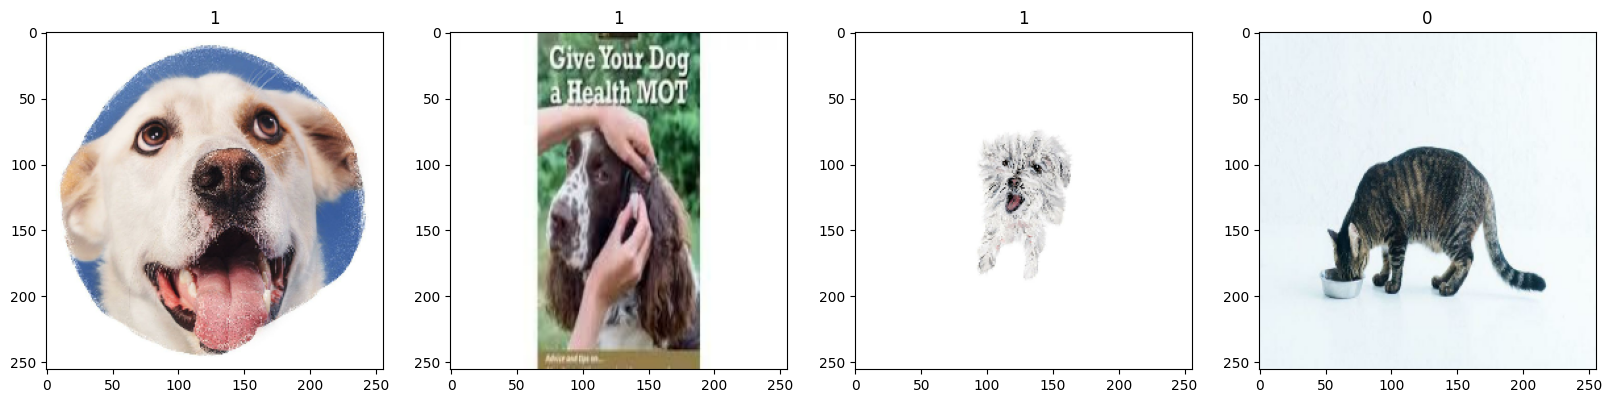

In [8]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for index, img in enumerate(batch[0][:4]):
  ax[index].imshow(img.astype(int))
  ax[index].title.set_text(batch[1][index])

This visual inspection acts as a sanity check before proceeding
to data preprocessing and model training.

## => Normalization

In [9]:
# normalization

data = data.map(lambda x,y: (x/255, y))


In [10]:
batch = data.as_numpy_iterator()
batch = batch.next()
batch

(array([[[[1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          ...,
          [1.        , 0.99215686, 0.99607843],
          [1.        , 0.99215686, 0.99607843],
          [1.        , 0.99215686, 0.99607843]],
 
         [[1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          ...,
          [1.        , 0.99215686, 0.99607843],
          [1.        , 0.99215686, 0.99607843],
          [1.        , 0.99215686, 0.99607843]],
 
         [[1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          ...,
          [1.        , 0.99215686, 0.99607843],
          [1.        , 0.99215686, 0.99607843],
          [1.        , 0.99215686, 0.99607843]],
 
         ...,
 
         [[0.99607843, 0.99607843, 0.99607843],
          [0.99607

Image pixel values originally range from 0 to 255.
Normalization was applied by scaling pixel values to the range [0, 1].

This step helps:
- Improve training stability
- Speed up convergence
- Prevent large gradient values during backpropagation

## => Splitting (Train / Validation / Test)

Splitting the dataset helps evaluate the model's ability
to generalize to unseen data and prevents overfitting.

In [12]:
len(data)

22

In [13]:
train_size = int(len(data) * 0.7)
test_size = int(len(data) * 0.2)
val_size = int(len(data) * 0.1)

In [14]:
train_size, test_size, val_size

(15, 4, 2)

In [15]:
train_data = data.take(train_size)
train_data

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [16]:
test_data = data.skip(train_size).take(test_size)
val_data = data.skip(train_size + test_size).take(val_size)

The dataset was split into three parts:
- Training set: used to train the CNN model
- Validation set: used to monitor performance during training
- Test set: used for final evaluation

## => Modeling

In [18]:
# modeling

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()

# conv
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D()) # pooling layer

# flatten layer
model.add(Flatten())

# hidden layer
model.add(Dense(256, activation='relu'))

# output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

Binary crossentropy is used for Binary classification problems.

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 258064)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    66,064,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,065,345 (252.02 MB)

 Trainable params: 66,065,345 (252.02 MB)

 Non-trainable params: 0 (0.00 B)

## => Model Training

The CNN model was trained using the training dataset.
Validation data was used to monitor performance during training and detect overfitting.

The model learns by adjusting weights over multiple epochs using backpropagation.

In [21]:
history = model.fit(train_data, epochs=10, validation_data=val_data)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.5229 - loss: 6.0460 - val_accuracy: 0.5000 - val_loss: 1.0372
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.6438 - loss: 1.0958 - val_accuracy: 0.6875 - val_loss: 0.6878
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.7833 - loss: 0.5071 - val_accuracy: 0.6875 - val_loss: 0.6803
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8542 - loss: 0.3868 - val_accuracy: 0.8750 - val_loss: 0.5400
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9375 - loss: 0.2069 - val_accuracy: 0.9375 - val_loss: 0.1944
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.9771 - loss: 0.1201 - val_accuracy: 0.9531 - val_loss: 0.1560
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9771 - loss: 0.1049 - val_accuracy: 0.9531 - val_loss: 0.0922
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.9854 - loss: 0.0655 - val_accuracy: 0.9531 - val_loss:

## => Model Evaluation

After training the CNN model, it is evaluated using the test dataset to measure its performance on unseen data.


In [23]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 874ms/step - accuracy: 0.9766 - loss: 0.0654
Test Loss: 0.06541409343481064
Test Accuracy: 0.9765625


In [24]:
# Precision and Recall Evaluation
from tensorflow.keras.metrics import Precision, Recall
import numpy as np

Pre = Precision()
Rec = Recall()

for batch in test_data.as_numpy_iterator():
    x, y = batch
    y_hat = model.predict(x)
    Pre.update_state(y, y_hat)
    Rec.update_state(y, y_hat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [25]:
print("Precision:", Pre.result().numpy())
print("Recall:", Rec.result().numpy())

Precision: 1.0
Recall: 0.9859155


The model shows moderate accuracy (97%), while precision and recall are higher (~100%).
This indicates that the model performs excellent

# Training vs Validation Loss

This plot shows the change in training and validation loss over epochs.


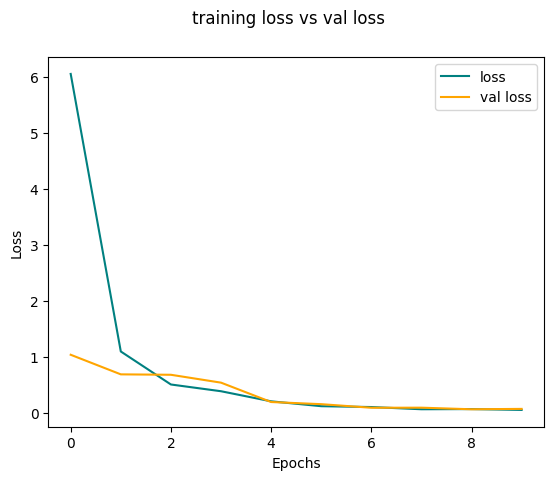

In [26]:
# loss

fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val loss')

fig.suptitle('training loss vs val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [27]:
img = '/content/drive/MyDrive/dog.jpg'

In [28]:
# resize
resized_img = tf.image.resize(cv2.imread(img), (256, 256))

# normalize
normalized_img = resized_img / 255

In [29]:
result = model.predict(np.expand_dims(normalized_img, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [31]:
if result > 0.5:
  print('dog')
else:
  print('cat')

dog


In [35]:
img = '/content/drive/MyDrive/cat.jpg'

In [36]:
# resize
resized_img = tf.image.resize(cv2.imread(img), (256, 256))

# normalize
normalized_img = resized_img / 255

In [37]:
result = model.predict(np.expand_dims(normalized_img, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [38]:
if result > 0.5:
  print('dog')
else:
  print('cat')

cat


In [39]:
# save model

model.save('cat_dog_classifier.h5')

In [40]:
from tensorflow.keras.models import load_model

model = load_model('cat_dog_classifier.h5')

In [41]:
img = '/content/drive/MyDrive/cat.jpg'

In [42]:
resized_img = tf.image.resize(cv2.imread(img), (256, 256))

# normalize
normalized_img = resized_img / 255
result = model.predict(np.expand_dims(normalized_img, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


In [43]:
if result > 0.5:
  print('dog')
else:
  print('cat')

cat
